In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import polars as pl
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, Normalizer, StandardScaler

from src.data import DatasetLoader, GraphBuilder, Preprocessor
from src.db import PBWarehouse
from src.matplotlib import Styles
from src.models import Features

plt.style.use(Styles.ML.value)

pb = PBWarehouse()
dataset_loader = DatasetLoader(pb=pb)

2025-09-03 08:22:24.060 | INFO     | src.config:<module>:27 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-09-03 08:22:24.061 | INFO     | src.config:<module>:64 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-09-03 08:22:24.061 | INFO     | src.config:<module>:65 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data
2025-09-03 08:22:25.734 | INFO     | src.matplotlib.color:<module>:103 - Accessible color palette inspired by https://github.com/mpetroff/accessible-color-cycles.


In [2]:
dataset_loader = DatasetLoader(pb=pb)
data: pl.DataFrame = dataset_loader.load_dataset(dtype=pl.DataFrame)

✅ Loading cached dataset - Done.
✅ Loading dataset - Done.


In [3]:
dataset_loader.update_cache()

✅ Fetching data (may take a few minutes or more) - Done.
Dataset cached at /home/iragca/Documents/github/capstone-project-2/data/.cache/dataset_cache.csv
✅ Updating cache - Done.


bookmark_count,favorite_count,favourites_count,follower_count,following_count,friends,is_blue_verified,is_hateful,listed_count,number_of_tweets,quote_count,reply_count,retweet_count,source,tweet_id,user_id,views
i64,i64,i64,i64,i64,i64,bool,str,i64,i64,i64,i64,i64,str,str,str,i64
0,0,941,39,6,6,false,"""1""",0,422,0,0,0,"""""","""1269916756719685632""","""1264846057906806786""",0
23,4860,13269,95956,1596,1595,true,"""1""",245,21715,28,334,156,"""""","""1277976913743503365""","""23719684""",0
0,2,1494,1394,427,427,false,"""1""",30,1173,0,0,0,"""Hootsuite Inc.""","""1285714950896443395""","""1081973336010309632""",0
0,4,2675,49,165,165,false,"""1""",3,1866,0,1,0,"""""","""1284209535561818112""","""190751291""",0
0,2,6,214664,258,258,false,"""1""",0,310173,1,7,1,"""Twitter Media Studio - LiveCut""","""1279563405536325632""","""121639467""",0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,1,2447,468,979,0,true,"""""",3,4284,0,1,1,"""Twitter Web App""","""1269054693323530241""","""426170736""",0
14,3034,532,30305,234,233,false,"""""",217,2069,86,40,1378,"""Twitter for Android""","""1274010135606620161""","""2904953395""",0
0,0,3071,54046,52576,0,true,"""""",382,28706,0,0,1,"""Twitter Web App""","""1284986922490720257""","""14870085""",0


In [3]:
# data = dataset_loader.update_cache()

In [4]:
preprocessor = Preprocessor(data=data)
df = preprocessor.preprocess()
df

✅ Categorizing source column - Done.
✅ Preprocessing data - Done.


bookmark_count,favorite_count,favourites_count,follower_count,following_count,friends,is_blue_verified,is_hateful,listed_count,number_of_tweets,quote_count,reply_count,retweet_count,source,tweet_id,user_id,views
i64,i64,i64,i64,i64,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,941,39,6,6,false,1,0,422,0,0,0,0,1269916756719685632,1264846057906806786,0
23,4860,13269,95956,1596,1595,true,1,245,21715,28,334,156,0,1277976913743503365,23719684,0
0,2,1494,1394,427,427,false,1,30,1173,0,0,0,0,1285714950896443395,1081973336010309632,0
0,4,2675,49,165,165,false,1,3,1866,0,1,0,0,1284209535561818112,190751291,0
0,2,6,214664,258,258,false,1,0,310173,1,7,1,0,1279563405536325632,121639467,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,1,2447,468,979,0,true,1,3,4284,0,1,1,0,1269054693323530241,426170736,0
14,3034,532,30305,234,233,false,1,217,2069,86,40,1378,0,1274010135606620161,2904953395,0
0,0,3071,54046,52576,0,true,1,382,28706,0,0,1,0,1284986922490720257,14870085,0


In [5]:
df["source"].value_counts()

source,count
i64,u32
0,35917


In [6]:
encoder = LabelEncoder()
encoder.fit(df["source"])

df.with_columns(
    pl.col("source").map_elements(
        lambda x: encoder.transform([x])[0] if isinstance(x, str) else x,
        return_dtype=pl.Int64,
    )
)

bookmark_count,favorite_count,favourites_count,follower_count,following_count,friends,is_blue_verified,is_hateful,listed_count,number_of_tweets,quote_count,reply_count,retweet_count,source,tweet_id,user_id,views
i64,i64,i64,i64,i64,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,941,39,6,6,false,1,0,422,0,0,0,128,1269916756719685632,1264846057906806786,0
23,4860,13269,95956,1596,1595,true,1,245,21715,28,334,156,128,1277976913743503365,23719684,0
0,2,1494,1394,427,427,false,1,30,1173,0,0,0,43,1285714950896443395,1081973336010309632,0
0,4,2675,49,165,165,false,1,3,1866,0,1,0,128,1284209535561818112,190751291,0
0,2,6,214664,258,258,false,1,0,310173,1,7,1,122,1279563405536325632,121639467,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,1,230,1182,30,30,false,1,0,2480,0,0,0,119,1275176503236612097,708865524751572992,0
0,2,411,42,83,83,false,1,0,256,0,0,1,117,1272830576140136448,2189107029,0
2,64,19738,13636,453,453,false,1,102,4005,1,0,9,119,1266939509251473409,271747129,0


In [10]:
encoder.transform(["twitter for iphone"])[0]

np.int64(119)

In [7]:
encoder.classes_

array(['2obytweeder', 'agorapulse app', 'airtime pro', 'amplifr',
       'anonymized', 'apphi', 'beb8a4c254', 'black cosmopolitian',
       'blackbeautygear', 'blackbird video platform/amplify',
       'blerds online database', 'blog2social app', 'brandwatch',
       'bso alert', 'buffer app', 'canva', 'cattweeter213', 'chirr.app',
       'commun.it intelligence', 'conservative daily news',
       'constant contact', 'coschedule', 'crowdfire app', 'daddy doggo',
       'declan mcgee', 'diggit magazine', 'dlvr.it', 'dynamic signal',
       'dynamic tweets', 'echofon', 'elgato stream deck', 'emplifi',
       'etsy', 'falcon pro 2015', 'fedica', 'fenix 2',
       'flamingo for android', 'gain platform', 'godaddy social app',
       'grabyo', 'grouptweet', 'hacker noon', 'heyorca', 'hootsuite inc.',
       'hubspot', 'ifttt', 'instagram', 'jenkers eng posting',
       'jetpack.com', 'joelotter_ebks', 'khoros publishing',
       'khoros publishing app', 'later media',
       'link account w

In [9]:
encoder = LabelEncoder()

encoder.fit_transform(df["source"])


array([  0,   0,  40, ..., 118, 112, 118], shape=(35917,))

In [ ]:
import re


def categorize_source_str(text: str) -> str:

    if len(text) == 0:
        return "unknown"

    if re.search(r"^erased.*", text):
        return "anonymized"

    return text.lower()

df.with_columns(
    pl.col("source").map_elements(categorize_source_str, return_dtype=pl.Utf8).alias("source")
)

bookmark_count,favorite_count,favourites_count,follower_count,following_count,friends,is_blue_verified,is_hateful,listed_count,number_of_tweets,quote_count,reply_count,retweet_count,source,tweet_id,user_id,views
i64,i64,i64,i64,i64,i64,bool,i64,i64,i64,i64,i64,i64,str,i64,i64,i64
0,0,941,39,6,6,false,1,0,422,0,0,0,"""unknown""",1269916756719685632,1264846057906806786,0
23,4860,13269,95956,1596,1595,true,1,245,21715,28,334,156,"""unknown""",1277976913743503365,23719684,0
0,2,1494,1394,427,427,false,1,30,1173,0,0,0,"""hootsuite inc.""",1285714950896443395,1081973336010309632,0
0,4,2675,49,165,165,false,1,3,1866,0,1,0,"""unknown""",1284209535561818112,190751291,0
0,2,6,214664,258,258,false,1,0,310173,1,7,1,"""twitter media studio - livecut""",1279563405536325632,121639467,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,1,230,1182,30,30,false,1,0,2480,0,0,0,"""twitter for iphone""",1275176503236612097,708865524751572992,0
0,2,411,42,83,83,false,1,0,256,0,0,1,"""twitter for android""",1272830576140136448,2189107029,0
2,64,19738,13636,453,453,false,1,102,4005,1,0,9,"""twitter for iphone""",1266939509251473409,271747129,0


In [10]:
encoder.classes_

array(['', '2obyTweeder', 'Agorapulse app', 'Airtime Pro', 'Amplifr',
       'Apphi', 'BEB8A4C254', 'BSO Alert', 'Black Cosmopolitian',
       'BlackBeautyGear', 'Blackbird Video Platform/Amplify',
       'Blerds Online Database', 'Blog2Social APP', 'Brandwatch',
       'Buffer App', 'Canva', 'CoSchedule', 'Commun.it Intelligence',
       'Conservative Daily News', 'Constant Contact', 'Crowdfire App',
       'Daddy Doggo', 'Declan McGee', 'Diggit magazine', 'Dynamic Signal',
       'Dynamic Tweets', 'Echofon', 'Elgato Stream Deck', 'Emplifi',
       'Etsy', 'Falcon Pro 2015', 'Fedica', 'Fenix 2',
       'Flamingo for Android', 'Gain Platform', 'GoDaddy Social App',
       'Grabyo', 'GroupTweet', 'Hacker Noon', 'HeyOrca', 'Hootsuite Inc.',
       'HubSpot', 'IFTTT', 'Instagram', 'Jenkers Eng Posting',
       'Jetpack.com', 'Khoros Publishing', 'Khoros Publishing App',
       'Later Media', 'Link account with KUKU.io', 'LinkedIn', 'Loomly',
       'Mailchimp', 'MammaDoggo', 'Mobile Web (

In [5]:
node_features = Features(
        tweet=[
            "favorite_count",
            "retweet_count",
            "bookmark_count",
            "reply_count",
            "quote_count",
            "views",
            # "is_hateful",
        ],
        user=[
            "favourites_count",
            "follower_count",
            # "following_count",
            "number_of_tweets",
            "listed_count",
            "is_blue_verified",
            "friends",
        ],
    )


gb = GraphBuilder(data=df, node_features=node_features)
G = gb.create_graph(nx.Graph)

In [ ]:
G.g

In [13]:
df['source'].value_counts().sort(by='count', descending=True).head(10)

source,count
str,u32
"""""",15802
"""Twitter for iPhone""",7929
"""Twitter Web App""",4196
"""Twitter for Android""",2819
"""Instagram""",989
"""Hootsuite Inc.""",463
"""TweetDeck""",448
"""Twitter for iPad""",325
"""Twitter Web Client""",261


In [6]:
df["source"]

source
str
""""""
""""""
"""Hootsuite Inc."""
""""""
"""Twitter Media Studio - LiveCut"""
…
"""Instagram"""
"""Twitter for Android"""
"""Instagram"""


In [5]:
data

bookmark_count,favorite_count,favourites_count,follower_count,following_count,is_blue_verified,is_hateful,listed_count,number_of_tweets,quote_count,reply_count,retweet_count,tweet_id,user_id,views
i64,i64,i64,i64,i64,bool,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,941,39,6,false,1,0,422,0,0,0,1269916756719685632,1264846057906806786,0
23,4860,13269,95956,1596,true,1,245,21715,28,334,156,1277976913743503365,23719684,0
0,2,1494,1394,427,false,1,30,1173,0,0,0,1285714950896443395,1081973336010309632,0
0,4,2675,49,165,false,1,3,1866,0,1,0,1284209535561818112,190751291,0
0,2,6,214664,258,false,1,0,310173,1,7,1,1279563405536325632,121639467,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,1550,1001,172,false,null,46,24072,0,0,0,1269881790409433088,44003537,0
0,3,125,17,3,false,null,0,77,0,0,2,1271295542195175425,1184368294335115264,0
0,0,593,85,255,false,null,0,1107,0,1,0,1276706305244307458,722778823960309761,0


In [3]:
data["is_hateful"].value_counts()

is_hateful,count
i8,u32
1,41251
0,78
2,872


In [2]:
data["number_of_tweets"].describe()

statistic,value
str,f64
"""count""",42201.0
"""null_count""",0.0
"""mean""",72301.816284
"""std""",216090.803262
"""min""",1.0
"""25%""",5771.0
"""50%""",20275.0
"""75%""",62566.0
"""max""",3.674318e6


In [ ]:
users_tweets_status = pb.client.collection("users_tweets_status").get_full_list()

In [5]:
full_tweets = [user.number_of_tweets for user in users_tweets_status]

In [ ]:
f"{sum(full_tweets) / 20:,.0f}"

'71,137,714'

In [8]:
31000 * 4

124000

In [11]:
data.filter(pl.col("number_of_tweets") < 5000)

tweet_id,bookmark_count,views,retweet_count,favorite_count,reply_count,quote_count,is_hateful,favourites_count,follower_count,following_count,is_blue_verified,listed_count,number_of_tweets,user_id
str,i64,i64,i64,i64,i64,i64,i8,i64,i64,i64,bool,i64,i64,str
"""1269916756719685632""",0,0,0,0,0,0,1,941,39,6,false,0,422,"""1264846057906806786"""
"""1285714950896443395""",0,0,0,2,0,0,1,1494,1394,427,false,30,1173,"""1081973336010309632"""
"""1284209535561818112""",0,0,0,4,1,0,1,2675,49,165,false,3,1866,"""190751291"""
"""1740477952499089608""",0,365,3,8,1,0,1,8592,8441,793,true,26,1889,"""1486020576716242950"""
"""1268693398854270976""",0,0,0,1,0,0,1,4746,716,1640,true,5,1233,"""2786302676"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""1283677981773385728""",0,0,0,1,0,0,1,976,123,1167,false,0,1564,"""3919100847"""
"""1244263237132193792""",0,0,0,0,0,0,1,2207,142,414,false,5,1348,"""380951792"""
"""1288260495514845185""",0,0,0,2,0,0,1,4973,3821,606,false,18,1515,"""1284582317348937729"""


In [7]:
f"{data["number_of_tweets"].sum() / 20:,.0f}"

'152,560,447'

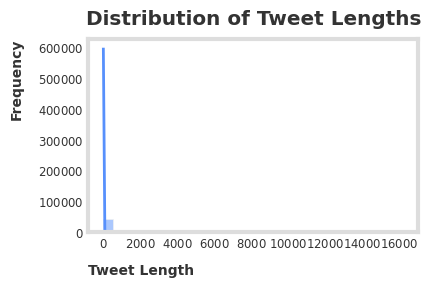

In [6]:
sns.histplot(data=data, x="bookmark_count", bins=30, kde=True)
plt.title("Distribution of Tweet Lengths")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

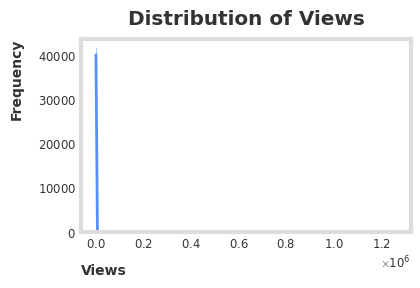

In [10]:
sns.histplot(data=data, x="views", kde=True)
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

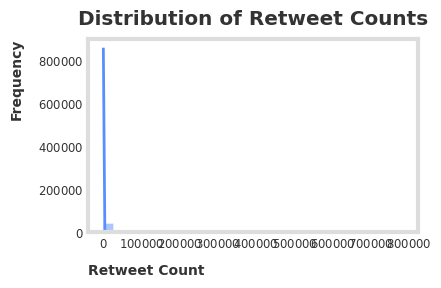

In [12]:
sns.histplot(data=data, x="retweet_count", bins=30, kde=True)
plt.title("Distribution of Retweet Counts")
plt.xlabel("Retweet Count")
plt.ylabel("Frequency")
plt.show()

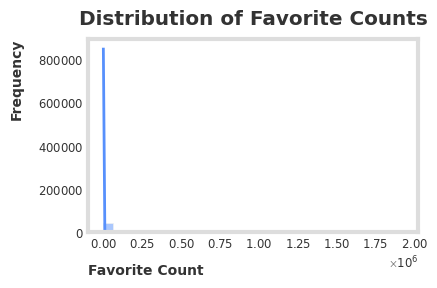

In [13]:
sns.histplot(data=data, x="favorite_count", bins=30, kde=True)
plt.title("Distribution of Favorite Counts")
plt.xlabel("Favorite Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
data["views"].describe()

statistic,value
str,f64
"""count""",42201.0
"""null_count""",0.0
"""mean""",467.72612
"""std""",10588.47298
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",0.0
"""max""",1.262165e6


In [8]:
data["bookmark_count"].describe()

statistic,value
str,f64
"""count""",42201.0
"""null_count""",0.0
"""mean""",4.028625
"""std""",124.802591
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",0.0
"""max""",16232.0


In [4]:
average_degree = G.number_of_edges() / G.number_of_nodes()

print(f"Average degree of the graph: {average_degree}")

Average degree of the graph: 0.5848983382073707


In [ ]:
from pprint import pprint

import torch
from deepsnap.dataset import GraphDataset

from src.architectures import HomoGNN
from src.config import PROJECT_ROOT
from src.data import DatasetLoader, GraphBuilder, Preprocessor
from src.db import PBWarehouse
from src.inference import InferenceResults
from src.models import Features, Graph, User
from src.scraper import TweetyScraper

model_path = PROJECT_ROOT / "best_model.pth"

pb = PBWarehouse()
scraper = TweetyScraper(previous_session=True)

model = HomoGNN(input_size=5, hidden_size=32)
model.load_state_dict(torch.load(model_path))
dataset_loader = DatasetLoader(pb)
data = dataset_loader.load_dataset()
preprocessor = Preprocessor(data=data)
data = preprocessor.preprocess()

node_features = Features(
    tweet=[
        "favorite_count",
        # "retweet_count",
        # "bookmark_count",
        "reply_count",
        "quote_count",
        # "views",
        "source",
        "is_hateful",
    ],
    user=[
        # "favourites_count",
        # "follower_count",
        # "following_count",
        # "number_of_tweets",
        # "listed_count",
        # "is_blue_verified",
        "friends",
    ],
)

gb = GraphBuilder(data=data, node_features=node_features)

graph: Graph = gb.create_graph()


username = "elonmusk"
user_id = None

if pb.does_user_exist(
    user_id=user_id, username=username, strict=False
):
    if user_id is not None:
        user_record = pb.get_user_by_id(user_id)
    else:
        user_record = pb.get_user_by_username(
            username, strict=False
        )
    user = User(**user_record.__dict__)

else:
    if user_id is not None:
        print(
            f"User {user_id} does not exist in the database. Fetching user info..."
        )

    if username is not None:
        print(
            f"User {username} does not exist in the database. Fetching user info..."
        )

    user: User = await scraper.get_user_info(user_id, username)
    pb.ingest_user(user)
    print(f"User {user.user_id} fetched successfully.")

print("Adding user to the graph...")
user_vector = gb.get_features(user.model_dump(), "user")
graph.add_node(
    int(user.user_id),
    node_label=3,
    node_feature=user_vector,
    node_type="user",
)

dataset = GraphDataset([graph], task="link_pred", edge_train_mode="disjoint")

model.eval()
with torch.no_grad():
    node_embeddings, edge_label_index = model(dataset[0])
    results = InferenceResults(
        graph=graph,
        node_embeddings=node_embeddings,
        edge_label_index=edge_label_index,
    )

    topk_results = results.get_top_k_similar_nodes_linked_to_user(
        user_id=int(user.user_id), descending=True, label=0
    )

    topk_results = [
        (pb.get_tweet_by_id(node_id), probability)
        for node_id, probability in topk_results
    ]

    print(f"Top similar nodes linked to user {user.user_id}:")
    pprint(topk_results)




✅ Loading cached dataset - Done.
✅ Loading dataset - Done.
✅ Categorizing source column - Done.
✅ Preprocessing data - Done.
Adding user to the graph...
Top similar nodes linked to user 44196397:
[(<Record: h08dlmv7ue63hta>, 0.5135294795036316),
 (<Record: yf4swl3t3h2e343>, 0.5128620862960815),
 (<Record: 3c2umoben4zdb9c>, 0.511626660823822),
 (<Record: mmbv87nulsjrumr>, 0.5102800130844116),
 (<Record: far5mu6wxyhzauo>, 0.5100211501121521),
 (<Record: 2ul1l5e6avhzudv>, 0.506888747215271),
 (<Record: rdqmkgj2361yjjl>, 0.5059724450111389),
 (<Record: m0hp877ot4ggfzt>, 0.5058199167251587),
 (<Record: yak8c8w9xrrzx3u>, 0.5050485730171204),
 (<Record: 0w2fcyhh6gz2wj2>, 0.5043224692344666)]


In [5]:
results.get_node_using_node_index(2)

(1277976913743503365,
 {'node_label': 1,
  'node_feature': tensor([4.8600e+03, 3.3400e+02, 2.8000e+01, 0.0000e+00, 1.0000e+00]),
  'node_type': 'tweet'})

In [ ]:
results.get